# Initiate

In [1]:
from openai import OpenAI
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

In [ ]:
openrouter_api = "YOUR_API_KEY"
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=openrouter_api,
)

# Test (Skip if tested)

In [ ]:
expert_prompt_4 = 'You are a renowned materials science engineering professor with extensive knowledge in the field. Your students have presented you with a challenging multiple-choice question related to materials science engineering. The question requires a detailed understanding and application of materials science principles. Please read the question carefully and provide a step-by-step explanation of your reasoning process, calculations, and analysis. Remember, the question has only one correct answer, which could be option (a), (b), (c), (d), etc. After carefully analyzing and calculating, please present the final answer at the end of your explanation. Your goal is to elucidate the concepts and problem-solving techniques in materials science engineering for your students.'

In [ ]:
def Answer_question(Question, Model = 'gpt-3.5-turbo-0613', Temperature = 0.0, expert = True, expert_prompt = expert_prompt_4):
    if expert == True:
        expert_prompt = expert_prompt
    else:
        expert_prompt = ''
    response = client.chat.completions.create(
      model= Model,
      messages=[{"role": "system", "content": expert_prompt},
                {"role": "user", "content": Question},
                ],
      temperature=Temperature,
    )
    return response.choices[0].message.content


def Check_answer(Question, Answer, right_answer, Model = 'openai/gpt-4o-2024-11-20', Temperature = 0.0):
    response = client.chat.completions.create(
      model= Model,
      messages=[{"role": "system", "content": 'You are to read the following text, which is the answer to a multiple choices question. The text should state the final answer (option (a), (b), (c), or (d)). You are to compare the stated answer with the correct answer: ' + str(right_answer) + '. If the stated answer is correct, please type 1, otherwise type 0. '+ 'If the final answer is not one of the options or report multiple options, it is considered wrong (you should type 0)' + ' Do not type anything else other than 1 or 0.'},
                {"role": "user", "content":  'Answer: ' + Answer + '\nQuestion: ' + Question + '\nRight Answer: ' + str(right_answer) + '\n1 or 0: '},
                ],
      temperature=Temperature,
      max_tokens=1,
    )
    return response.choices[0].message.content

In [ ]:
mcq_df = pd.read_csv('MSE-MCQs.csv',encoding='unicode_escape')

In [ ]:
# Define your model here
Model = "Your Model"

In [ ]:
count = 0
for Question in mcq_df['Question'][:]:
    for i in range(1,4):
        Answerwo = Answer_question(Question, Model = Model, expert = False)
        mcq_df.loc[mcq_df['Question'] == Question, 'Answer w/o Expert '+str(i)] = Answerwo
        time.sleep(3)
        Answerw = Answer_question(Question, Model = Model, expert = True, expert_prompt = expert_prompt_4)
        mcq_df.loc[mcq_df['Question'] == Question, 'Answer w/ Expert 4 '+str(i)] = Answerw
        time.sleep(3)
    count += 1
    print(count)

In [ ]:
# If above code fails, run this code to resume from the last checkpoint
for index, row in mcq_df.iterrows():
    question = row['Question']
    
    # Check if the question has already been processed (all answers filled)
    if not mcq_df.loc[index, 'Answer w/o Expert 1':'Answer w/ Expert 4 3'].isnull().any():
        continue  # Skip already processed questions
    
    count = 0  # Counter for tracking progress
    
    try:
        for i in range(1, 4):
            # Answer without expert
            if pd.isnull(mcq_df.loc[index, f'Answer w/o Expert {i}']):
                answer_wo = Answer_question(question, Model=Model, expert=False)
                mcq_df.loc[index, f'Answer w/o Expert {i}'] = answer_wo
                time.sleep(3)
            
            # Answer with expert
            if pd.isnull(mcq_df.loc[index, f'Answer w/ Expert 4 {i}']):
                answer_w = Answer_question(question, Model=Model, expert=True, expert_prompt=expert_prompt_4)
                mcq_df.loc[index, f'Answer w/ Expert 4 {i}'] = answer_w
                time.sleep(3)
        
        count += 1
        print(f"Processed {count} questions.")
    
    except Exception as e:
        print(f"Error encountered at question {index}: {e}")
        # Save progress to file in case of error
        mcq_df.to_csv("mcq_checkpoint_Your_Model.csv", index=False)
        break

# Save final progress
mcq_df.to_csv("mcq_final_Your_Model.csv", index=False)


# Check (Skip if checked)

In [ ]:
# Loop through columns that contain 'Answer w/' in their names
for col in mcq_df.columns[mcq_df.columns.str.contains('Answer w/')]:
    for index, row in mcq_df.iterrows():
        # Get the Question and the corresponding Answer
        Question = row['Question']
        Answer = row[col]

        # Skip processing if the Answer is 'unknown'
        if Answer == 'unknown':
            mcq_df.loc[index, col.replace('Answer', 'Check')] = '0'
            continue

        # Retrieve the right answer
        try:
            right_answer = row['True Answer']
        except KeyError:
            print(f"Missing 'True Answer' column for row {index}")
            mcq_df.loc[index, col.replace('Answer', 'Check')] = 'error'
            continue

        # Check the answer
        try:
            check = Check_answer(Question, Answer, right_answer)
        except Exception as e:
            print(f"Error checking answer for Question {index}: {e}")
            mcq_df.loc[index, col.replace('Answer', 'Check')] = 'error'
            continue

        # Save the result of the check in the corresponding 'Check' column
        if check in ['1', '0']:
            mcq_df.loc[index, col.replace('Answer', 'Check')] = check
        else:
            mcq_df.loc[index, col.replace('Answer', 'Check')] = 'error'

        # Pause to avoid overloading the checking process
        time.sleep(1)
        
mcq_df.to_csv("mcq_final_Your_Model_checked.csv", index=False)


# Plot

In [2]:
# Older LLMs
llama2_7b_eval_df = pd.read_csv('mcq_final_llama-2-7b-chat-all with expert 4 checked.csv', encoding='unicode_escape')
llama2_13b_eval_df = pd.read_csv('mcq_final_llama-2-13b-chat-all with expert 4 checked.csv')
llama2_70b_eval_df = pd.read_csv('mcq_final_llama-2-70b-chat-all with expert 4 checked.csv')
gpt_35_turbo_eval_df = pd.read_csv('gpt-3.5-turbo-0613_all_original_eval_with_expert_4_checked.csv', encoding='unicode_escape')
gpt_4_eval_df = pd.read_csv('gpt-4-0613_all_original_eval_with_expert_4_checked.csv', encoding='unicode_escape')

In [3]:
# Newer LLMs
claude_35_sonnet_20240620 = pd.read_csv('mcq_final_claude-3.5-sonnet-20240620_checked_withquestion_manualchecked.csv', encoding='unicode_escape')
llama33_70B_instruct = pd.read_csv('mcq_final_llama3.3-70B-instruct_checked_withquestion_manualchecked.csv', encoding='unicode_escape')
gpt4o_20241120 = pd.read_csv("mcq_final_GPT-4o (2024-11-20)_checked_withquestion_manualchecked.csv", encoding='unicode_escape')
deepseek_r1 = pd.read_csv("mcq_final_deepseek-r1_checked_withquestion_manualchecked.csv", encoding='unicode_escape')

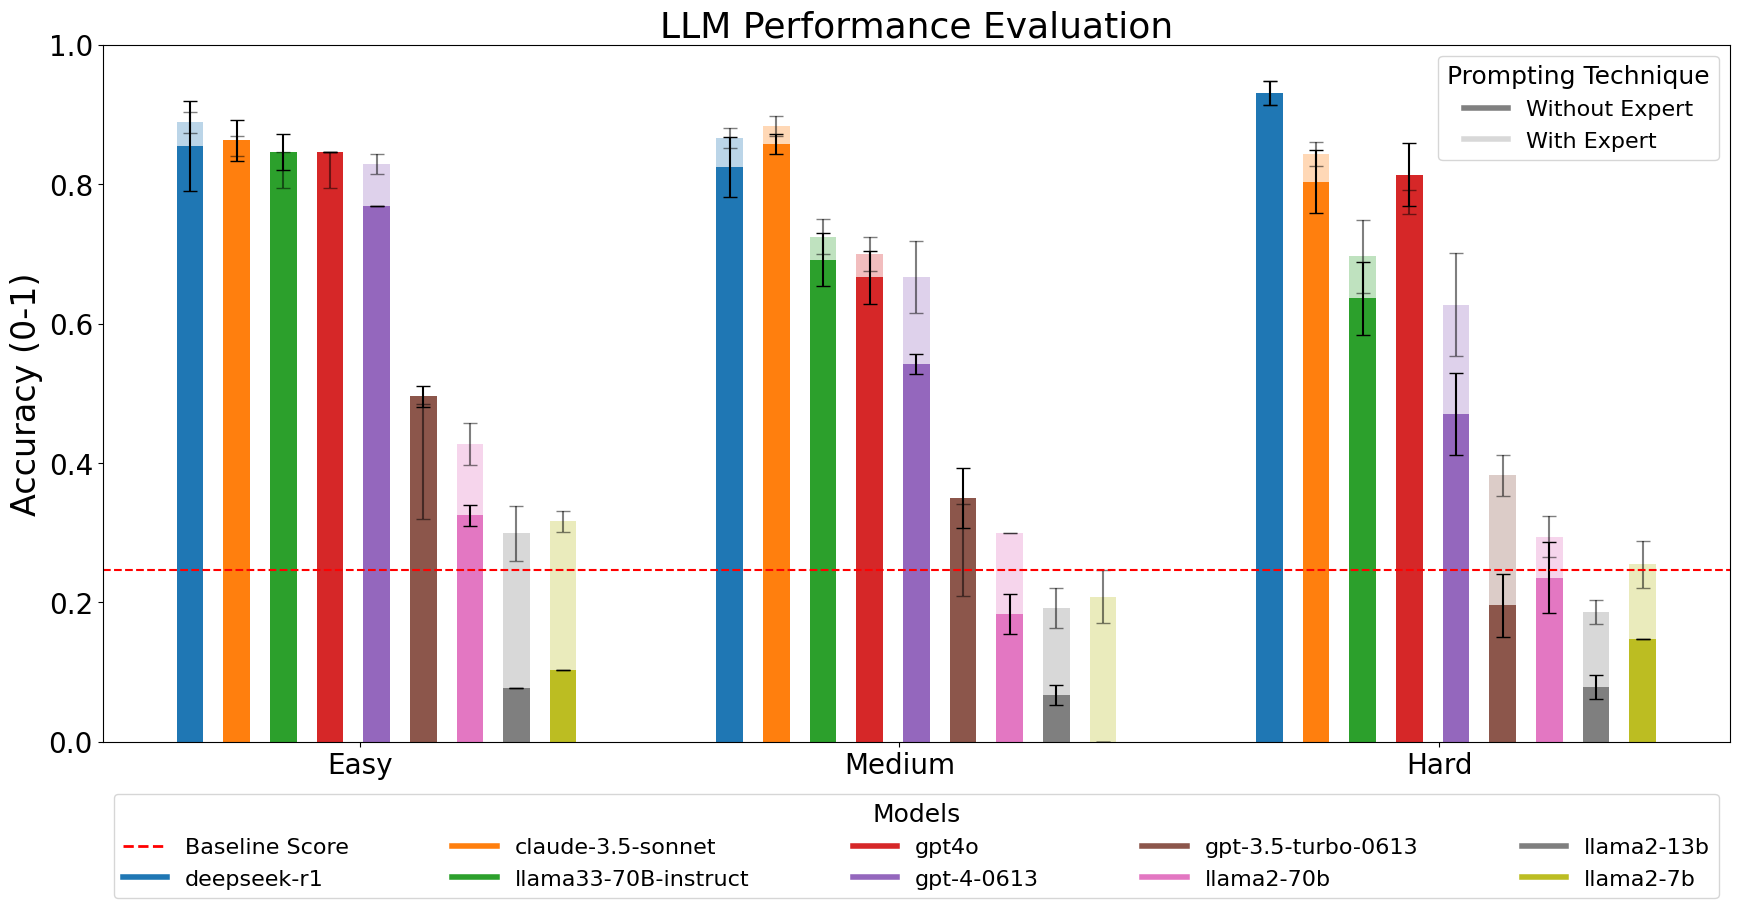

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def get_avg_std_fixed_alignment_superimposed(df_list):
    # Define bar properties
    n_difficulties = 3  # Number of difficulty levels: Easy, Medium, Hard
    n_models = len(df_list)
    bar_width = 0.4  # Bar width for better alignment
    bar_gap = 0.1  # Gap between "w/o Expert" and "w/ Expert" bars
    group_width = n_models * (2 * bar_width + bar_gap)  # Total width for one difficulty group

    # Prepare the plot
    fig, ax = plt.subplots(figsize=(13 + n_models * 0.5, 8))

    # Define a list of colors for "w/o Expert" and lighter shades for "w/ Expert"
    base_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    if n_models > len(base_colors):
        base_colors = base_colors * ((n_models // len(base_colors)) + 1)

    # Function to add labels on top of each bar
    def add_bar_labels(bars, errors, alpha=1):
        for bar, err in zip(bars, errors):
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',  # Format value to 2 decimal places
                        xy=(bar.get_x() + bar.get_width() / 2, height + err + 0.02),  
                        xytext=(0, 6),  # Vertical offset
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=12, color='black', alpha=alpha)

    # Iterate through each difficulty and model
    for difficulty_idx, difficulty in enumerate(['Easy', 'Medium', 'Hard']):
        for model_idx, df in enumerate(df_list):
            if not hasattr(df, 'name'):
                df.name = f"Model {model_idx + 1}"  # Assign a generic name if missing

            # Calculate base position for the group and individual bars
            group_base_position = difficulty_idx * group_width
            model_offset = model_idx * (1.5 * bar_width + bar_gap)
            base_position = group_base_position + model_offset

            # Filter data for difficulty level
            df_diff = df[df['Difficulty'] == difficulty] if 'Difficulty' in df.columns else None
            check_wo_cols = [col for col in df.columns if 'Check w/o Expert' in col]
            check_w_cols = [col for col in df.columns if 'Check w/ Expert' in col]

            if df_diff is not None and check_wo_cols and check_w_cols:
                check_wo_avg = df_diff[check_wo_cols].mean().mean()
                check_wo_std = df_diff[check_wo_cols].mean().std()
                check_w_avg = df_diff[check_w_cols].mean().mean()
                check_w_std = df_diff[check_w_cols].mean().std()
            else:
                # Skip if required columns or data are missing
                continue

            # Plot the "w/ Expert" bar first (to be behind)
            bars_w = ax.bar(base_position, check_w_avg, bar_width, alpha=0.3, color=base_colors[model_idx],
                            label=f'{df.name} w/ Expert' if (difficulty_idx == 0 and model_idx == 0) else "")
            ax.errorbar(base_position, check_w_avg, yerr=check_w_std, ecolor='black', capsize=5, alpha=0.5)
            #add_bar_labels(bars_w, [check_w_std], alpha= 0.6)  # Add labels for "w/ Expert"

            # Plot the "w/o Expert" bar on top
            bars_wo = ax.bar(base_position, check_wo_avg, bar_width, alpha=1, color=base_colors[model_idx],
                             label=f'{df.name} w/o Expert' if (difficulty_idx == 0 and model_idx == 0) else "")
            ax.errorbar(base_position, check_wo_avg, yerr=check_wo_std, ecolor='black', capsize=5, alpha=1)
            #add_bar_labels(bars_wo, [check_wo_std])  # Add labels for "w/o Expert"

    # Set up labels, title, and legend
    ax.set_ylabel('Accuracy (0-1)', fontsize=24)
    ax.set_title('LLM Performance Evaluation', fontsize=26)

    central_positions = [
        (difficulty_idx * group_width + (group_width - ((n_models - 4.7) * (1.5 * bar_width + bar_gap))) / 2)
        for difficulty_idx in range(n_difficulties)
    ]  
    ax.set_xticks(central_positions)
    ax.set_xticklabels(['Easy', 'Medium', 'Hard'], fontsize=24)

    ax.set_ylim(0, 1)
    ax.tick_params(axis='both', which='major', labelsize=20)

    # Baseline Score
    ax.axhline(y=0.246, color='red', linestyle='--', label='Baseline Score')

    # Custom legends for models and techniques
    model_legend = [
        plt.Line2D([0], [0], color='red', lw=2, linestyle='--', label='Baseline Score')
    ] + [plt.Line2D([0], [0], color=color, lw=4) for color in base_colors[:n_models]]
    technique_legend = [
        plt.Line2D([0], [0], color='gray', lw=4, alpha=1, label='Without Expert'),
        plt.Line2D([0], [0], color='gray', lw=4, alpha=0.3, label='With Expert')
    ]

    # Add model legend including Baseline Score
    model_legend_obj = ax.legend(handles=model_legend, labels=['Baseline Score'] + [df.name for df in df_list], 
                                 title='Models', fontsize=16, title_fontsize=18, loc='lower left',bbox_to_anchor=(0,-0.24,1,0.2), mode = 'expand', ncol = 5)
    ax.add_artist(model_legend_obj)  # Add model legend separately

    # Add technique legend
    ax.legend(handles=technique_legend, title='Prompting Technique', fontsize=16, title_fontsize=18, loc='upper right')

    # Display the plot
    plt.tight_layout()
    plt.show()


# Example usage:
datasets = [deepseek_r1, claude_35_sonnet_20240620, llama33_70B_instruct, gpt4o_20241120, gpt_4_eval_df, gpt_35_turbo_eval_df, llama2_70b_eval_df, llama2_13b_eval_df, llama2_7b_eval_df]
gpt_35_turbo_eval_df.name = "gpt-3.5-turbo-0613"
gpt_4_eval_df.name = "gpt-4-0613"
llama2_7b_eval_df.name = "llama2-7b"
llama2_13b_eval_df.name = "llama2-13b"
llama2_70b_eval_df.name = "llama2-70b"
claude_35_sonnet_20240620.name = "claude-3.5-sonnet"
llama33_70B_instruct.name = "llama33-70B-instruct"
gpt4o_20241120.name = "gpt4o"
deepseek_r1.name = "deepseek-r1"

for idx, df in enumerate(datasets):
    if not hasattr(df, 'name'):
        df.name = f"Dataset {idx + 1}"

get_avg_std_fixed_alignment_superimposed(datasets)
